## Import Dataset from kagglehub

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("msambare/fer2013")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'fer2013' dataset.
Path to dataset files: /kaggle/input/fer2013


## Import Libraries

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import os

## Identify Train & Test directories

In [ ]:
train_dir = '/kaggle/input/fer2013/train'
val_dir   = '/kaggle/input/fer2013/test'

## Image augmentation & preprocessing

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255, # Normalize pixel values
    rotation_range=15, # Random rotation up to 15 degrees
    width_shift_range=0.1, # Randomly shifts images horizontally by up to 10% of the width
    height_shift_range=0.1, # Randomly shifts images vertically by up to 10% of the height
    horizontal_flip=True # Randomly flips images horizontally
)
val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(48,48), # Resizing to 48*48 pixels
    color_mode='grayscale',
    batch_size=64, # images in each batch
    class_mode='categorical'
)
val_gen = val_datagen.flow_from_directory(
    val_dir,
    target_size=(48,48),
    color_mode='grayscale',
    batch_size=64,
    class_mode='categorical'
)

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


In [ ]:
model = Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(48,48,1)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Conv2D(128,(3,3),activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Flatten(),
    Dense(256,activation='relu'),
    Dropout(0.5),
    Dense(train_gen.num_classes,activation='softmax')
])

model.compile(optimizer=Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 46, 46, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 21, 21, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 619,911 (2.36 MB)

 Trainable params: 619,463 (2.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
history = model.fit(train_gen, validation_data=val_gen, epochs=15)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 171s 362ms/step - accuracy: 0.1996 - loss: 2.6469 - val_accuracy: 0.2967 - val_loss: 1.8599
Epoch 2/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 37s 82ms/step - accuracy: 0.2458 - loss: 1.8376 - val_accuracy: 0.3281 - val_loss: 1.7228
Epoch 3/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 36s 81ms/step - accuracy: 0.2647 - loss: 1.7967 - val_accuracy: 0.3497 - val_loss: 1.7048
Epoch 4/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 36s 80ms/step - accuracy: 0.2831 - loss: 1.7594 - val_accuracy: 0.3710 - val_loss: 1.6089
Epoch 5/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 37s 82ms/step - accuracy: 0.2996 - loss: 1.7363 - val_accuracy: 0.3809 - val_loss: 1.5829
Epoch 6/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 37s 83ms/step - accuracy: 0.3234 - loss: 1.6981 - val_accuracy: 0.3717 - val_loss: 1.6276
Epoch 7/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 36s 81ms/step - accuracy: 0.3422 - loss: 1.6666 - val_accuracy: 0.4178 - val_loss: 1.5003
Epoch 8/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 36s 81ms/step - accuracy: 0.3592 - loss: 1.6395 

In [ ]:
loss, acc = model.evaluate(val_gen)
print(f"\n✅ Validation Accuracy: {acc*100:.2f}%")

113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - accuracy: 0.4511 - loss: 1.4070

✅ Validation Accuracy: 46.07%


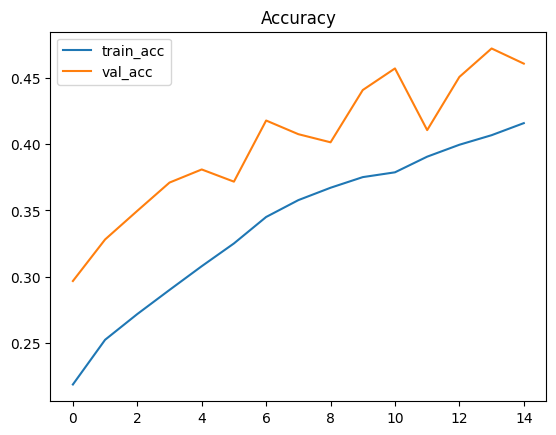

In [ ]:
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.title('Accuracy')
plt.show()